1

In [4]:
import networkx as nx
import numpy as np
import random
import pandas as pd

# --- Load the dataset ---
# Download: https://snap.stanford.edu/data/facebook_combined.txt.gz
G = nx.read_edgelist("facebook_combined.txt", nodetype=int)

# Convert to directed graph (so in/out degree centrality exist explicitly)
G = G.to_directed()

# --- Create samples A and B ---
nodes = list(G.nodes())
random.seed(42)

A_nodes = set(random.sample(nodes, 2000))
B_nodes = set(nodes) - A_nodes

# Induced subgraphs (keep only edges within each sample)
G_A = G.subgraph(A_nodes)
G_B = G.subgraph(B_nodes)

# --- Function to compute metrics ---
def compute_metrics(G_sub):
    in_deg = list(nx.in_degree_centrality(G_sub).values())
    out_deg = list(nx.out_degree_centrality(G_sub).values())
    closeness = list(nx.closeness_centrality(G_sub).values())
    betweenness = list(nx.betweenness_centrality(G_sub).values())

    return {
        "in_degree_mean": np.mean(in_deg),
        "in_degree_std": np.std(in_deg),
        "out_degree_mean": np.mean(out_deg),
        "out_degree_std": np.std(out_deg),
        "closeness_mean": np.mean(closeness),
        "closeness_std": np.std(closeness),
        "betweenness_mean": np.mean(betweenness),
        "betweenness_std": np.std(betweenness),
    }

# --- Compute for A and B ---
metrics_A = compute_metrics(G_A)
metrics_B = compute_metrics(G_B)

# --- Display as table ---
df = pd.DataFrame([metrics_A, metrics_B], index=["Sample A", "Sample B"])
print(df)

          in_degree_mean  in_degree_std  out_degree_mean  out_degree_std  \
Sample A        0.010236       0.012456         0.010236        0.012456   
Sample B        0.011393       0.013950         0.011393        0.013950   

          closeness_mean  closeness_std  betweenness_mean  betweenness_std  
Sample A        0.185291       0.061548          0.001753         0.017750  
Sample B        0.156835       0.077186          0.000923         0.010249  


2

In [5]:
sizes = [500, 1000, 1500, 2000, 2500]

def compute_metrics(G_sub):
    in_deg = list(nx.in_degree_centrality(G_sub).values())
    out_deg = list(nx.out_degree_centrality(G_sub).values())
    closeness = list(nx.closeness_centrality(G_sub).values())
    betweenness = list(nx.betweenness_centrality(G_sub, k=100, seed=42).values())  # faster

    return [
        np.mean(in_deg), np.std(in_deg),
        np.mean(out_deg), np.std(out_deg),
        np.mean(closeness), np.std(closeness),
        np.mean(betweenness), np.std(betweenness)
    ]

results = []

for size in sizes:
    A_nodes = set(random.sample(nodes, size))
    B_nodes = set(nodes) - A_nodes

    G_A = G.subgraph(A_nodes)
    G_B = G.subgraph(B_nodes)

    metrics_A = compute_metrics(G_A)
    metrics_B = compute_metrics(G_B)

    results.append(["A", size] + metrics_A)
    results.append(["B", len(B_nodes)] + metrics_B)

columns = [
    "Sample", "Size",
    "in_deg_mean", "in_deg_std",
    "out_deg_mean", "out_deg_std",
    "closeness_mean", "closeness_std",
    "betweenness_mean", "betweenness_std"
]

df = pd.DataFrame(results, columns=columns)
print(df)

  Sample  Size  in_deg_mean  in_deg_std  out_deg_mean  out_deg_std  \
0      A   500     0.011719    0.016370      0.011719     0.016370   
1      B  3539     0.010757    0.012582      0.010757     0.012582   
2      A  1000     0.011684    0.016178      0.011684     0.016178   
3      B  3039     0.010538    0.011887      0.010538     0.011887   
4      A  1500     0.010205    0.011887      0.010205     0.011887   
5      B  2539     0.011110    0.013616      0.011110     0.013616   
6      A  2000     0.011100    0.013569      0.011100     0.013569   
7      B  2039     0.010521    0.012710      0.010521     0.012710   
8      A  2500     0.010638    0.013354      0.010638     0.013354   
9      B  1539     0.011281    0.012992      0.011281     0.012992   

   closeness_mean  closeness_std  betweenness_mean  betweenness_std  
0        0.073084       0.065324          0.001065         0.008255  
1        0.215970       0.054547          0.000818         0.009134  
2        0.164076  

3

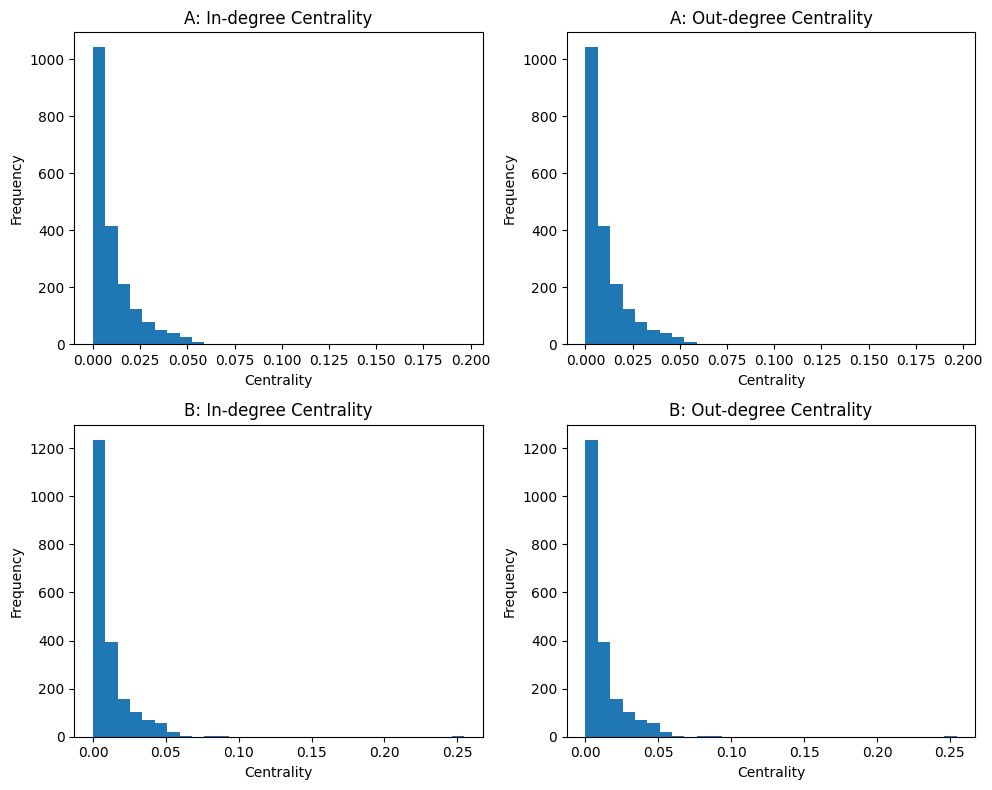

In [7]:
import matplotlib.pyplot as plt
# --- Create A and B (same as step 1) ---
A_nodes = set(random.sample(nodes, 2000))
B_nodes = set(nodes) - A_nodes

G_A = G.subgraph(A_nodes)
G_B = G.subgraph(B_nodes)

# --- Compute centralities ---
in_A = list(nx.in_degree_centrality(G_A).values())
out_A = list(nx.out_degree_centrality(G_A).values())

in_B = list(nx.in_degree_centrality(G_B).values())
out_B = list(nx.out_degree_centrality(G_B).values())

# --- Plot ---
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# A - In-degree
axes[0, 0].hist(in_A, bins=30)
axes[0, 0].set_title("A: In-degree Centrality")

# A - Out-degree
axes[0, 1].hist(out_A, bins=30)
axes[0, 1].set_title("A: Out-degree Centrality")

# B - In-degree
axes[1, 0].hist(in_B, bins=30)
axes[1, 0].set_title("B: In-degree Centrality")

# B - Out-degree
axes[1, 1].hist(out_B, bins=30)
axes[1, 1].set_title("B: Out-degree Centrality")

for ax in axes.flat:
    ax.set_xlabel("Centrality")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

4

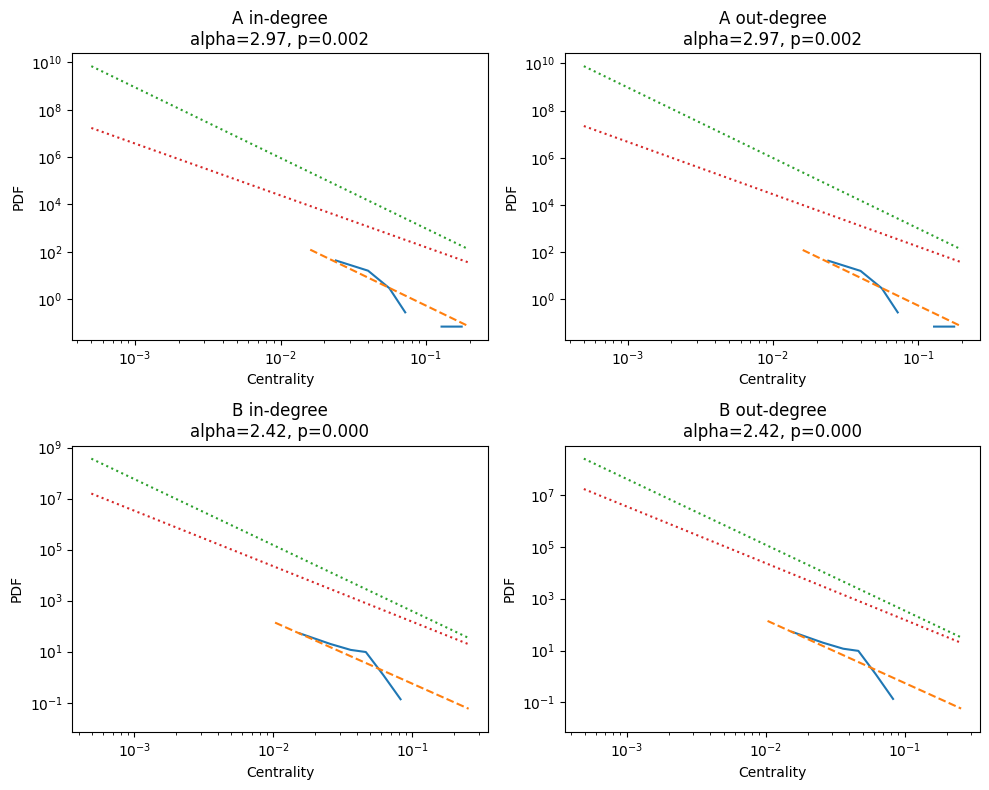

In [8]:
import powerlaw
# --- centralities (reuse your G_A, G_B) ---
in_A  = np.array(list(nx.in_degree_centrality(G_A).values()))
out_A = np.array(list(nx.out_degree_centrality(G_A).values()))
in_B  = np.array(list(nx.in_degree_centrality(G_B).values()))
out_B = np.array(list(nx.out_degree_centrality(G_B).values()))

# remove zeros (required for power-law fitting)
datasets = {
    "A in-degree":  in_A[in_A > 0],
    "A out-degree": out_A[out_A > 0],
    "B in-degree":  in_B[in_B > 0],
    "B out-degree": out_B[out_B > 0],
}

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, (title, data) in zip(axes.flat, datasets.items()):
    fit = powerlaw.Fit(data, verbose=False)

    # empirical PDF
    fit.plot_pdf(ax=ax)

    # fitted power-law
    fit.power_law.plot_pdf(ax=ax, linestyle='--')

    # bootstrap for 90% CI
    alphas = []
    for _ in range(100):
        sample = np.random.choice(data, size=len(data), replace=True)
        f = powerlaw.Fit(sample, verbose=False)
        alphas.append(f.alpha)

    alpha_low, alpha_high = np.percentile(alphas, [5, 95])

    # plot bounds
    x = np.linspace(min(data), max(data), 100)
    y_low  = x ** (-alpha_high)
    y_high = x ** (-alpha_low)

    ax.plot(x, y_low, linestyle=':')
    ax.plot(x, y_high, linestyle=':')

    # goodness-of-fit vs lognormal
    R, p = fit.distribution_compare('power_law', 'lognormal')

    ax.set_title(f"{title}\nalpha={fit.alpha:.2f}, p={p:.3f}")
    ax.set_xlabel("Centrality")
    ax.set_ylabel("PDF")

plt.tight_layout()
plt.show()

5

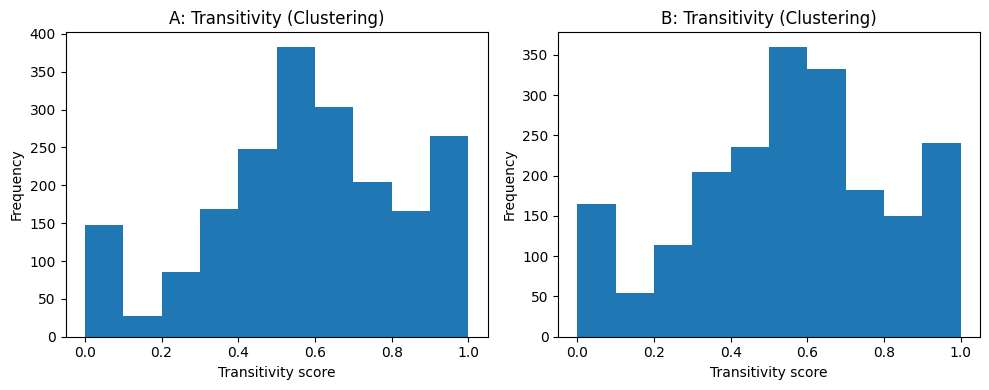

In [9]:
# --- Node-level transitivity (clustering) ---
clust_A = list(nx.clustering(G_A.to_undirected()).values())
clust_B = list(nx.clustering(G_B.to_undirected()).values())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(clust_A, bins=10)
axes[0].set_title("A: Transitivity (Clustering)")

axes[1].hist(clust_B, bins=10)
axes[1].set_title("B: Transitivity (Clustering)")

for ax in axes:
    ax.set_xlabel("Transitivity score")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

6

A: #communities = 52 modularity = 0.8428950459354457
B: #communities = 79 modularity = 0.8304653927785794


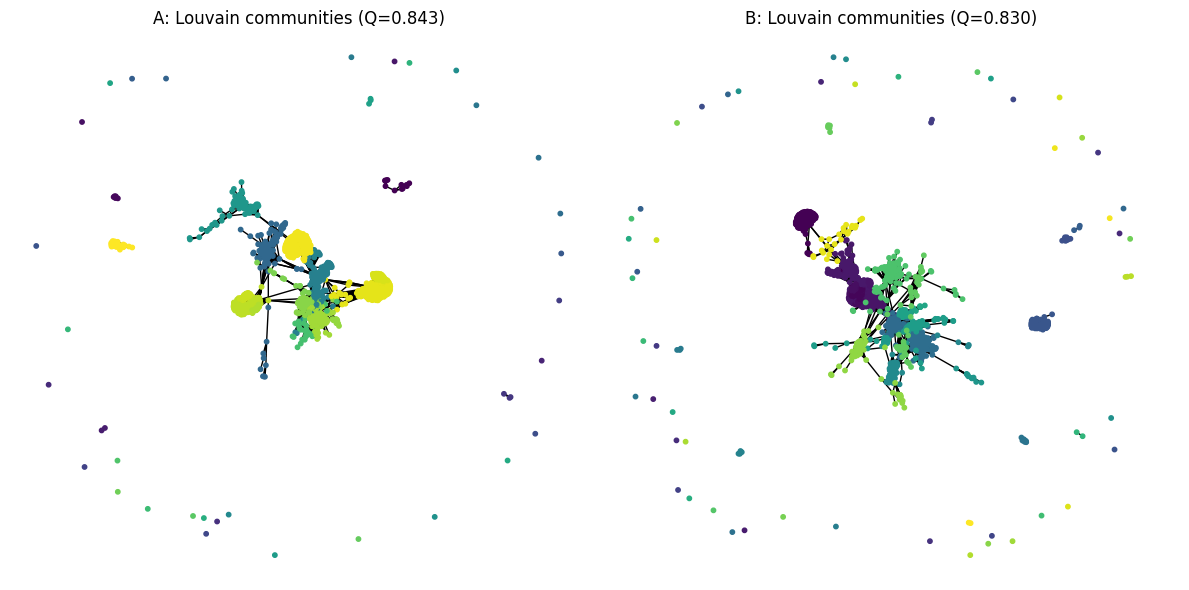

A: avg conductance = 0.03715186758014076
B: avg conductance = 0.033802911058231196


In [11]:
# --- Louvain (requires: pip install python-louvain OR networkx >= 3.0) ---
from networkx.algorithms.community import louvain_communities
from networkx.algorithms.community.quality import modularity
from networkx.algorithms.cuts import conductance
from networkx.algorithms.cuts import volume

# Louvain expects undirected graphs
GA_u = G_A.to_undirected()
GB_u = G_B.to_undirected()

# --- Detect communities ---
comms_A = louvain_communities(GA_u, seed=42)
comms_B = louvain_communities(GB_u, seed=42)

# --- Modularity (separation quality) ---
mod_A = modularity(GA_u, comms_A)
mod_B = modularity(GB_u, comms_B)

print("A: #communities =", len(comms_A), "modularity =", mod_A)
print("B: #communities =", len(comms_B), "modularity =", mod_B)

# --- Helper: map node -> community id ---
def node_colors(G, communities):
    cmap = {}
    for i, c in enumerate(communities):
        for n in c:
            cmap[n] = i
    return [cmap[n] for n in G.nodes()]

# --- Layout (same seed for reproducibility) ---
pos_A = nx.spring_layout(GA_u, seed=42)
pos_B = nx.spring_layout(GB_u, seed=42)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

nx.draw(GA_u, pos_A,
        node_color=node_colors(GA_u, comms_A),
        node_size=10, with_labels=False, ax=axes[0])
axes[0].set_title(f"A: Louvain communities (Q={mod_A:.3f})")

nx.draw(GB_u, pos_B,
        node_color=node_colors(GB_u, comms_B),
        node_size=10, with_labels=False, ax=axes[1])
axes[1].set_title(f"B: Louvain communities (Q={mod_B:.3f})")

plt.tight_layout()
plt.show()

# --- Optional extra quality measures ---
# conductance (lower is better), averaged over communities
from networkx.algorithms.cuts import conductance


def avg_conductance(G, communities):
    vals = []
    for c in communities:
        if 0 < len(c) < G.number_of_nodes():
            vol_c = volume(G, c)
            vol_rest = volume(G, set(G.nodes()) - set(c))
            
            # skip problematic cases
            if vol_c == 0 or vol_rest == 0:
                continue

            vals.append(conductance(G, c))

    return np.mean(vals) if len(vals) > 0 else float('nan')

print("A: avg conductance =", avg_conductance(GA_u, comms_A))
print("B: avg conductance =", avg_conductance(GB_u, comms_B))

7

In [15]:
def community_stats(G, communities):
    rows = []

    for i, c in enumerate(communities):
        subG = G.subgraph(c)

        n = subG.number_of_nodes()

        # clustering (global for subgraph)
        clustering = nx.average_clustering(subG)

        # handle disconnected graphs
        if nx.is_connected(subG):
            diameter = nx.diameter(subG)
            avg_path = nx.average_shortest_path_length(subG)
        else:
            # take largest connected component
            largest_cc = max(nx.connected_components(subG), key=len)
            subG_cc = subG.subgraph(largest_cc)

            diameter = nx.diameter(subG_cc)
            avg_path = nx.average_shortest_path_length(subG_cc)

        rows.append([i, n, clustering, diameter, avg_path])

    return pd.DataFrame(rows, columns=[
        "community", "num_nodes", "clustering", "diameter", "avg_path_length"
    ])

# --- Apply to A and B ---
df_A = community_stats(GA_u, comms_A)
df_B = community_stats(GB_u, comms_B)

print("A communities:")
print(df_A)

print("\nB communities:")
print(df_B)

A communities:
    community  num_nodes  clustering  diameter  avg_path_length
0           0         12    0.744444         4         2.257576
1           1          5    1.000000         1         1.000000
2           2          1    0.000000         0         0.000000
3           3          1    0.000000         0         0.000000
4           4          2    0.000000         1         1.000000
5           5          1    0.000000         0         0.000000
6           6          1    0.000000         0         0.000000
7           7          1    0.000000         0         0.000000
8           8          3    1.000000         1         1.000000
9           9          1    0.000000         0         0.000000
10         10          1    0.000000         0         0.000000
11         11          1    0.000000         0         0.000000
12         12          1    0.000000         0         0.000000
13         13          1    0.000000         0         0.000000
14         14          1 

8

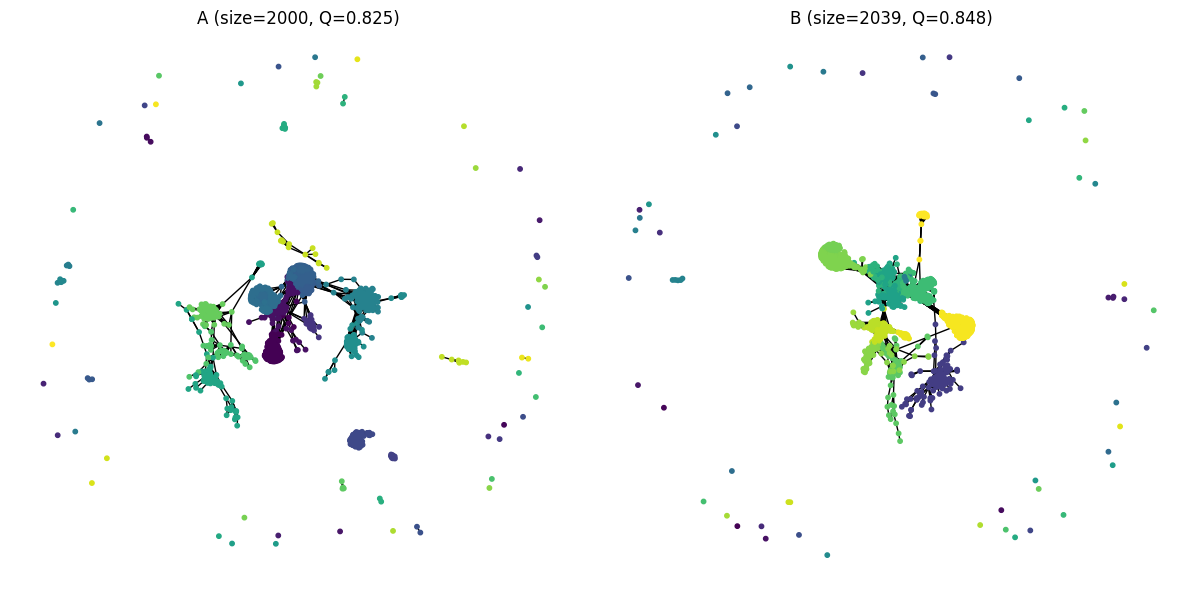

  Sample  Size  #communities  Modularity  Avg Conductance
0      A   500           135    0.898978         0.007593
1      B  3539            17    0.829666         0.063538
2      A  1000            75    0.848008         0.033926
3      B  3039            62    0.828585         0.023781
4      A  1500            79    0.830966         0.020814
5      B  2539            60    0.839238         0.035867
6      A  2000            74    0.824708         0.027327
7      B  2039            68    0.848119         0.034536
8      A  2500            73    0.827022         0.031043
9      B  1539            73    0.850350         0.026134


In [16]:
results = []
community_tables = {}

def community_stats(G, communities):
    rows = []
    for i, c in enumerate(communities):
        subG = G.subgraph(c)
        n = subG.number_of_nodes()
        clustering = nx.average_clustering(subG)

        if nx.is_connected(subG):
            diameter = nx.diameter(subG)
            avg_path = nx.average_shortest_path_length(subG)
        else:
            largest_cc = max(nx.connected_components(subG), key=len)
            subG = subG.subgraph(largest_cc)
            diameter = nx.diameter(subG)
            avg_path = nx.average_shortest_path_length(subG)

        rows.append([i, n, clustering, diameter, avg_path])

    return pd.DataFrame(rows, columns=[
        "community", "num_nodes", "clustering", "diameter", "avg_path_length"
    ])

def node_colors(G, communities):
    cmap = {}
    for i, c in enumerate(communities):
        for n in c:
            cmap[n] = i
    return [cmap[n] for n in G.nodes()]

for size in sizes:
    A_nodes = set(random.sample(nodes, size))
    B_nodes = set(nodes) - A_nodes

    GA_u = G.subgraph(A_nodes).to_undirected()
    GB_u = G.subgraph(B_nodes).to_undirected()

    comms_A = louvain_communities(GA_u, seed=42)
    comms_B = louvain_communities(GB_u, seed=42)

    mod_A = modularity(GA_u, comms_A)
    mod_B = modularity(GB_u, comms_B)

    cond_A = avg_conductance(GA_u, comms_A)
    cond_B = avg_conductance(GB_u, comms_B)

    results.append(["A", size, len(comms_A), mod_A, cond_A])
    results.append(["B", len(B_nodes), len(comms_B), mod_B, cond_B])

    # store per-community tables
    community_tables[f"A_{size}"] = community_stats(GA_u, comms_A)
    community_tables[f"B_{len(B_nodes)}"] = community_stats(GB_u, comms_B)

    # --- visualize only for one size (e.g. 2000) to avoid clutter ---
    if size == 2000:
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))

        nx.draw(GA_u, node_color=node_colors(GA_u, comms_A),
                node_size=10, with_labels=False, ax=axes[0])
        axes[0].set_title(f"A (size={size}, Q={mod_A:.3f})")

        nx.draw(GB_u, node_color=node_colors(GB_u, comms_B),
                node_size=10, with_labels=False, ax=axes[1])
        axes[1].set_title(f"B (size={len(B_nodes)}, Q={mod_B:.3f})")

        plt.tight_layout()
        plt.show()

# --- summary table ---
df_summary = pd.DataFrame(results, columns=[
    "Sample", "Size", "#communities", "Modularity", "Avg Conductance"
])

print(df_summary)